# ASMR 字幕

为了正常运行，请选择带 GPU 的运行时环境。

- 可通过 **运行时 → 更改运行时类型 → GPU T4** 选择显卡

---
*强烈不建议使用需要下载的本地 AI 模型。使用本地模型很容易导致显存（VRAM）不足并程序崩溃。建议优先使用 API 翻译。如果你有轻量智能模型（例如 8B），可以尝试把它的名称加入 `AVAILABLE_MODELS` 和 `selected_model_name`。*

In [ ]:
#@title 1. 安装依赖

#@markdown - 提示重启运行时是正常现象

#@markdown - 重启后需要重新运行此单元格

import os
import subprocess

!apt-get update -qq && apt-get install -y ffmpeg

!pip install --upgrade pip
!pip install gradio torch torchaudio torchvision --index-url https://download.pytorch.org/whl/cu121

!pip install git+https://github.com/m-bain/whisperx.git

!pip install transformers accelerate bitsandbytes sentencepiece

!pip install deepl

!pip install deep-translator

!pip install -q -U google-genai

!pip install pydub webvtt-py

print("✅ 依赖安装完成！")

In [ ]:
#@title 2. 填写你的密钥 { form-width: "20%", display-mode: "form" }
#@markdown - HF_TOKEN — 获取地址 [HuggingFace](https://huggingface.co/settings/tokens)

#@markdown - DEEPL_API_KEY — 获取地址 [DeepL](https://www.deepl.com/pro-api)

#@markdown - GROQ_API_KEY — 获取地址 [Groq](https://console.groq.com/keys)

#@markdown - GEMINI_API_KEY — 获取地址 [Gemini](https://aistudio.google.com/apikey)

#@markdown - 使用说话人分离前，请先接受 [speaker-diarization-community-1](https://huggingface.co/pyannote/speaker-diarization-community-1) 的使用条款

import os
from getpass import getpass

HF_TOKEN = ""  # @param {type:"string"}
#@markdown
DEEPL_API_KEY = ""  # @param {type:"string"}
#@markdown
GROQ_API_KEY = ""   # @param {type:"string"}
#@markdown 没有 Groq API 密钥时，开启说话人分离后不会自动命名角色！
# DeepSeek 可选 / 付费
#DEEPSEEK_API_KEY = ""  # @param {type:"string"}

GEMINI_API_KEY = ""  # @param {type:"string"}

#@markdown 小提示：Gemini 比较敏感。如果它拒绝翻译某些内容，会自动回退到 Google 翻译。

if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
    print("✅ HF_TOKEN 已设置")

if DEEPL_API_KEY:
    os.environ["DEEPL_API_KEY"] = DEEPL_API_KEY
    print("✅ DeepL API Key 已设置")

if GROQ_API_KEY:
    os.environ["GROQ_API_KEY"] = GROQ_API_KEY
    print("✅ Groq API Key 已设置")

'''if DEEPSEEK_API_KEY:
    os.environ["DEEPSEEK_API_KEY"] = DEEPSEEK_API_KEY
    print("✅ DeepSeek API Key 已设置")'''

if GEMINI_API_KEY:
    os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY
    print("✅ Gemini API Key 已设置")

print("\n完成！现在可以在界面中选择 API。")

In [ ]:
#@title 连接 Google Drive
from google.colab import drive
import os

drive.mount('/content/drive')

# 所有文件保存的根目录
DRIVE_BASE = "/content/drive/MyDrive/ASMR_ENGINEERING"

# 在网盘中创建所需文件夹
os.makedirs(DRIVE_BASE, exist_ok=True)
os.makedirs(f"{DRIVE_BASE}/input", exist_ok=True)
os.makedirs(f"{DRIVE_BASE}/ASMR_transcription", exist_ok=True)
os.makedirs(f"{DRIVE_BASE}/ASMR_Resultat", exist_ok=True)
os.makedirs(f"{DRIVE_BASE}/ASMR_Original", exist_ok=True)

print("✅ Google Drive 已连接")
print(f"工作目录: {DRIVE_BASE}")

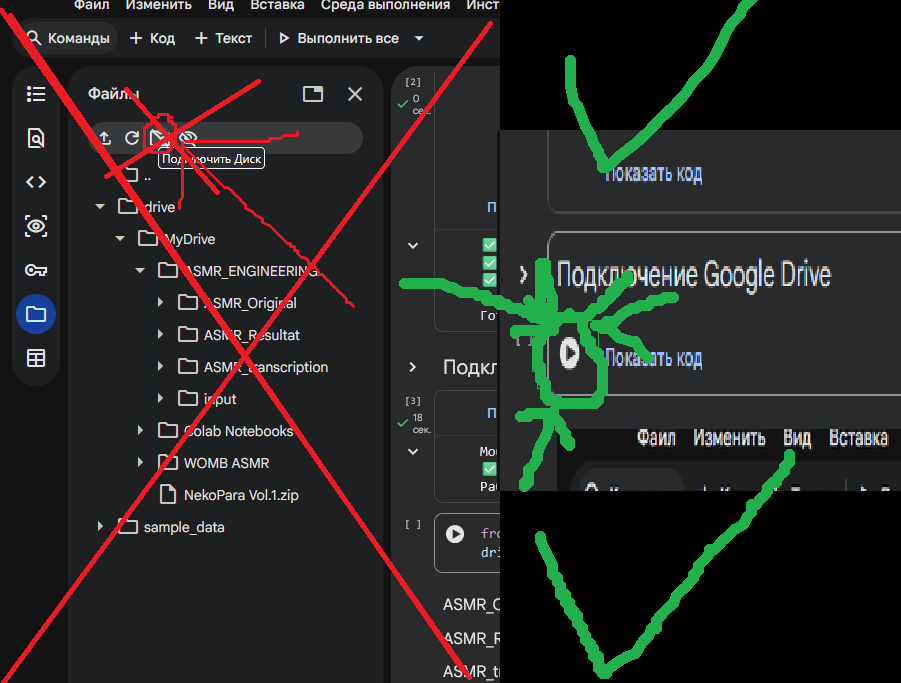

ASMR_Original - 未翻译的文件，但已按字幕格式整理

ASMR_Resultat - 已翻译的文件

ASMR_transcription - 未翻译的 txt 格式文件

input - 将要处理的原始文件

In [ ]:
#@title 3. 启动 GUI

import os
import whisperx
import torch
import gradio as gr
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import gc
import webvtt
from datetime import timedelta
import uuid
from pydub import AudioSegment
import requests
import time
import re

def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.reset_accumulated_memory_stats()

        if hasattr(torch.cuda, 'reset_max_memory_allocated'):
            torch.cuda.reset_max_memory_allocated()

    if torch.cuda.is_available():
        allocated = torch.cuda.memory_allocated() / 1024**3
        reserved = torch.cuda.memory_reserved() / 1024**3

# ===================== 文件夹设置 =====================
DRIVE_BASE = "/content/drive/MyDrive/ASMR_ENGINEERING"

TEMP_DIR = "/tmp/ASMR_TEMP"
os.makedirs(TEMP_DIR, exist_ok=True)

INPUT_DIR = os.path.join(DRIVE_BASE, "input")
TRANSCRIPTION_DIR = os.path.join(DRIVE_BASE, "ASMR_transcription")
RESULT_DIR = os.path.join(DRIVE_BASE, "ASMR_Resultat")
ORIGINAL_SUBTITLES_DIR = os.path.join(DRIVE_BASE, "ASMR_Original")

for d in [INPUT_DIR, TRANSCRIPTION_DIR, RESULT_DIR, ORIGINAL_SUBTITLES_DIR]:
    os.makedirs(d, exist_ok=True)

# ===================== 模型加载 =====================
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"使用设备: {device}")

# WhisperX

whisper_model = None

def load_whisper(model_name="large-v3", vad_enabled=True, beam_size=5):
    global whisper_model
    if whisper_model is None or getattr(whisper_model, 'config_key', None) != (model_name, vad_enabled, beam_size):
        print(f"正在加载 {model_name} | VAD={'ON' if vad_enabled else 'OFF'} | Beam={beam_size}")

        whisper_model = whisperx.load_model(
            model_name,
            device,
            compute_type="float16",
            vad_method="pyannote" if vad_enabled else None,
            vad_options={
                "max_silence_time": 400,      # 片段之间的静音
                "min_speech_time": 250,       # 最小语音时长
                "speech_pad": 0.1},
            asr_options={
                "beam_size": int(beam_size),
                "condition_on_previous_text": False,
                "word_timestamps": True
            }
        )
        whisper_model.config_key = (model_name, vad_enabled, beam_size)
    return whisper_model

qwen_model = None
qwen_tokenizer = None

translation_model = None
translation_tokenizer = None

# 可用模型列表
AVAILABLE_MODELS = {
    "Google Translate": "google",
    "DeepL": "deepl",
    "Gemini": "gemini",
    "Groq (Llama 3.3 70B)": "groq:llama-3.3-70b-versatile",
    "Groq (Qwen 3.6 27B)": "groq:qwen/qwen3.6-27b",
    "Qwen2.5": "Orion-zhen/Qwen2.5-7B-Instruct-Uncensored",
    "Dolphin 2.9.1": "cognitivecomputations/dolphin-2.9.1-llama-3-8b",
}

GROQ_SPEAKER_MODELS = {
    "None (不重命名)": "None",
    "Groq (Llama 3.3 70B)": "llama-3.3-70b-versatile",
    "Groq (Qwen 3.6 27b)": "qwen/qwen3.6-27b",
}

def load_qwen(model_name="Sao10K/Llama-3.1-8B-Stheno-v3.4"):
    global translation_model, translation_tokenizer

    if model_name in ["google", "deepl", "deepseek"]:
        return None, None

    if translation_model is None or getattr(translation_model, 'current_model', None) != model_name:

        print(f"正在加载翻译模型: {model_name}...")

        quantization_config = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_compute_dtype=torch.bfloat16,
            bnb_4bit_use_double_quant=True,
            bnb_4bit_quant_type="nf4"
        )

        translation_tokenizer = AutoTokenizer.from_pretrained(
            model_name, trust_remote_code=True
        )

        translation_model = AutoModelForCausalLM.from_pretrained(
            model_name,
            quantization_config=quantization_config,
            device_map="auto",
            trust_remote_code=True,
            torch_dtype=torch.bfloat16
        )

        translation_model.current_model = model_name
        print(f"✅ 模型 {model_name} 加载成功！")

    clear_memory()
    return translation_model, translation_tokenizer

# ===================== 辅助函数 =====================
def seconds_to_srt_time(seconds):
    td = timedelta(seconds=seconds)
    hours = td.seconds // 3600
    minutes = (td.seconds % 3600) // 60
    secs = td.seconds % 60
    millis = int(td.microseconds / 1000)
    return f"{hours:02}:{minutes:02}:{secs:02},{millis:03}"

def create_srt(segments, filename):
    path = os.path.join(RESULT_DIR, filename)
    with open(path, "w", encoding="utf-8") as f:
        for i, seg in enumerate(segments, 1):
            start = seconds_to_srt_time(seg["start"])
            end = seconds_to_srt_time(seg["end"])
            speaker = seg.get("speaker", "")
            text = seg["text"].strip()
            if speaker:
                text = f"{speaker}: {text}"
            f.write(f"{i}\n{start} --> {end}\n{text}\n\n")
    return path


def create_vtt(segments, filename):
    path = os.path.join(RESULT_DIR, filename)
    vtt = webvtt.WebVTT()
    for seg in segments:
        speaker = seg.get("speaker", "")
        text = seg["text"].strip()
        if speaker:
            text = f"{speaker}: {text}"
        caption = webvtt.Caption(
            start=seconds_to_srt_time(seg["start"]).replace(",", "."),
            end=seconds_to_srt_time(seg["end"]).replace(",", "."),
            text=text
        )
        vtt.captions.append(caption)
    vtt.save(path)
    return path


def create_lrc(segments, filename):
    path = os.path.join(RESULT_DIR, filename)
    with open(path, "w", encoding="utf-8") as f:
        for seg in segments:
            speaker = seg.get("speaker", "")
            text = seg["text"].strip()
            if speaker:
                text = f"{speaker}: {text}"
            minutes = int(seg["start"] // 60)
            seconds = seg["start"] % 60
            f.write(f"[{minutes:02}:{seconds:05.2f}]{text}\n")
    return path

def create_original_subtitles(segments, filename, output_format):
    path = os.path.join(ORIGINAL_SUBTITLES_DIR, filename)

    if output_format == "SRT":
        with open(path, "w", encoding="utf-8") as f:
            for i, seg in enumerate(segments, 1):
                start = seconds_to_srt_time(seg["start"])
                end = seconds_to_srt_time(seg["end"])
                speaker = seg.get("speaker", "")
                text = seg.get("text", "").strip()
                if speaker:
                    text = f"{speaker}: {text}"
                f.write(f"{i}\n{start} --> {end}\n{text}\n\n")

    elif output_format == "VTT":
        vtt = webvtt.WebVTT()
        for seg in segments:
            speaker = seg.get("speaker", "")
            text = seg.get("text", "").strip()
            if speaker:
                text = f"{speaker}: {text}"
            caption = webvtt.Caption(
                start=seconds_to_srt_time(seg["start"]).replace(",", "."),
                end=seconds_to_srt_time(seg["end"]).replace(",", "."),
                text=text
            )
            vtt.captions.append(caption)
        vtt.save(path)

    else:  # LRC
        with open(path, "w", encoding="utf-8") as f:
            for seg in segments:
                speaker = seg.get("speaker", "")
                text = seg.get("text", "").strip()
                if speaker:
                    text = f"{speaker}: {text}"
                minutes = int(seg["start"] // 60)
                seconds = seg["start"] % 60
                f.write(f"[{minutes:02}:{seconds:05.2f}]{text}\n")

    return path

def parse_srt(path):
    segments = []
    with open(path, "r", encoding="utf-8") as f:
        content = f.read().strip()

    blocks = re.split(r'\n\s*\n', content)
    for block in blocks:
        lines = block.strip().split('\n')
        if len(lines) < 3:
            continue
        time_line = lines[1]
        match = re.match(r'(\d{2}:\d{2}:\d{2},\d{3})\s*-->\s*(\d{2}:\d{2}:\d{2},\d{3})', time_line)
        if not match:
            continue
        start = srt_time_to_seconds(match.group(1))
        end = srt_time_to_seconds(match.group(2))
        text = ' '.join(lines[2:]).strip()
        segments.append({"start": start, "end": end, "text": text})
    return segments


def parse_vtt(path):
    segments = []
    vtt = webvtt.read(path)
    for caption in vtt:
        start = srt_time_to_seconds(caption.start.replace('.', ','))
        end = srt_time_to_seconds(caption.end.replace('.', ','))
        text = caption.text.strip().replace('\n', ' ')
        segments.append({"start": start, "end": end, "text": text})
    return segments


def parse_lrc(path):
    segments = []
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        match = re.match(r'\[(\d{2}):(\d{2}\.\d{2})\](.*)', line.strip())
        if match:
            minutes = int(match.group(1))
            seconds = float(match.group(2))
            start = minutes * 60 + seconds
            text = match.group(3).strip()
            end = start + 3.0
            if i + 1 < len(lines):
                next_match = re.match(r'\[(\d{2}):(\d{2}\.\d{2})\]', lines[i+1].strip())
                if next_match:
                    end = int(next_match.group(1)) * 60 + float(next_match.group(2))
            segments.append({"start": start, "end": end, "text": text})
    return segments


def srt_time_to_seconds(time_str):
    time_str = time_str.replace(',', '.')
    h, m, s = time_str.split(':')
    return int(h) * 3600 + int(m) * 60 + float(s)

def translate_text(text, target_lang="Russian", instructions="", glossary="",
                  selected_model_name=None, max_new_tokens=1024, temperature=0.85, output_format="SRT"):

    format_instruction = {
        "SRT": "SRT subtitles (with numbers and --> timestamps)",
        "VTT": "WebVTT subtitles (with timestamps in HH:MM:SS.mmm format)",
        "LRC": "LRC lyrics format (with [mm:ss.xx] timestamps)"
    }.get(output_format, "SRT subtitles")

    system_prompt = f"""You are a professional translator of ASMR audio scripts (including intimate and sensual content).

Your only task is to translate the given text into natural, emotional {target_lang}.

Strict rules:
1. Output ONLY the translated text. Nothing else.
2. Do not add timestamps, numbers, speaker labels, or any formatting.
3. Keep all moans, breathing and sound effects (ahh, mmm, nngh, haa...) as they are.
4. Preserve the intimate and atmospheric tone.
5. Do not censor the content.
6. Do not explain anything. Just give the pure translation.

Additional style: {instructions}
Glossary: {glossary if glossary else "None"}

Translate this text:"""

    model_key = AVAILABLE_MODELS.get(selected_model_name, selected_model_name)

# ====================== API 翻译器 ======================
    if model_key == "google":
        try:
            from deep_translator import GoogleTranslator

            google_lang_map = {
                "russian": "ru",
                "english": "en",
                "spanish": "es",
                "french": "fr",
                "german": "de",
                "japanese": "ja",
                "chinese": "zh-CN",
                "korean": "ko",
            }
            lang_code = google_lang_map.get(target_lang.lower(), target_lang[:2].lower())

            translator = GoogleTranslator(source='auto', target=lang_code)
            translated_text = translator.translate(text)
            return translated_text
        except Exception as e:
            print(f"❌ Google Translate 错误: {e}")
            return text

    elif model_key == "deepl":
        try:
            import deepl
            deepl_key = os.getenv("DEEPL_API_KEY")
            if not deepl_key:
                print("⚠️ 未找到 DeepL API Key！")
                return text
            translator = deepl.Translator(deepl_key)

            deepl_lang_map = {
                "russian": "RU",
                "english": "EN-US",
                "spanish": "ES",
                "french": "FR",
                "german": "DE",
                "japanese": "JA",
                "chinese": "ZH-HANS",
                "korean": "KO",
            }
            lang_code = deepl_lang_map.get(target_lang.lower())

            if not lang_code:
                print(f"⚠️ DeepL 不支持语言: {target_lang}")
                return text

            result = translator.translate_text(text, target_lang=lang_code)
            translated_text = result.text
            return translated_text
        except Exception as e:
            print(f"❌ DeepL 错误: {e}")
            return text

    elif model_key == "deepseek":
        deepseek_key = os.getenv("DEEPSEEK_API_KEY")
        if not deepseek_key:
            print("❌ 错误：未找到 DeepSeek API Key！")
            return text
        try:
            url = "https://api.deepseek.com/chat/completions"
            headers = {
                "Authorization": f"Bearer {deepseek_key}",
                "Content-Type": "application/json"
            }
            payload = {
                "model": "deepseek-v4-flash",
                "messages": [
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": text}
                ],
                "temperature": temperature,
                "max_tokens": max_new_tokens
            }
            response = requests.post(url, json=payload, headers=headers, timeout=90)
            response.raise_for_status()
            translated_text = response.json()["choices"][0]["message"]["content"].strip()
            return translated_text
        except Exception as e:
            print(f"❌ DeepSeek API 错误: {e}")
            return text

    elif model_key == "gemini":
        gemini_key = os.getenv("GEMINI_API_KEY")
        if not gemini_key:
            print("❌ 错误：未找到 Gemini API Key！")
            return text
        try:
            from google import genai
            import time

            client = genai.Client(api_key=gemini_key)

            time.sleep(3)

            response = client.models.generate_content(
                model="gemini-3.5-flash-lite",
                contents=[
                    {"role": "user", "parts": [{"text": f"{system_prompt}\n\nText to translate:\n{text}"}]}
                ]
            )

            if response and getattr(response, "text", None):
                translated_text = response.text.strip()
            else:
                print("⚠️ Gemini 返回空结果 → 回退到 Google 翻译")
                from deep_translator import GoogleTranslator
                google_lang_map = {
                    "russian": "ru",
                    "english": "en",
                    "spanish": "es",
                    "french": "fr",
                    "german": "de",
                    "japanese": "ja",
                    "chinese": "zh-CN",
                    "korean": "ko",
                }
                lang_code = google_lang_map.get(target_lang.lower(), "ru")
                translated_text = GoogleTranslator(source='auto', target=lang_code).translate(text)

            return translated_text

        except Exception as e:
            print(f"❌ Gemini API 错误: {e} → 回退到 Google 翻译")
            try:
                from deep_translator import GoogleTranslator
                google_lang_map = {
                    "russian": "ru",
                    "english": "en",
                    "spanish": "es",
                    "french": "fr",
                    "german": "de",
                    "japanese": "ja",
                    "chinese": "zh-CN",
                    "korean": "ko",
                }
                lang_code = google_lang_map.get(target_lang.lower(), "ru")
                return GoogleTranslator(source='auto', target=lang_code).translate(text)
            except Exception as e2:
                print(f"❌ Google 回退也失败了: {e2}")
                return text

    elif isinstance(model_key, str) and model_key.startswith("groq:"):
        api_key = os.getenv("GROQ_API_KEY")
        if not api_key:
            print("⚠️ 未找到 GROQ_API_KEY！")
            return text
        try:
            groq_model = model_key.replace("groq:", "", 1)
            headers = {
                "Authorization": f"Bearer {api_key}",
                "Content-Type": "application/json"
            }
            payload = {
                "model": groq_model,
                "messages": [
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": text}
                ],
                "temperature": temperature,
                "max_tokens": min(int(max_new_tokens), 2048),
            }
            response = requests.post(
                "https://api.groq.com/openai/v1/chat/completions",
                headers=headers,
                json=payload,
                timeout=90
            )
            response.raise_for_status()
            translated_text = response.json()["choices"][0]["message"]["content"].strip()
            return translated_text
        except Exception as e:
            print(f"❌ Groq 翻译错误: {e}")
            return text


    # ====================== 本地模型 ======================
    if selected_model_name in ["Qwen2.5", "Dolphin 2.9.1"]:
        print(f"🔄 正在加载本地模型: {selected_model_name}")

        model_key = AVAILABLE_MODELS[selected_model_name]
        model, tokenizer = load_qwen(model_key)

        if model is None:
            print("❌ 错误：模型未加载")
            return text

        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": text}
        ]

        text_input = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(text_input, return_tensors="pt").to(model.device)

        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                top_p=0.9,
                do_sample=True,
                repetition_penalty=1.15,
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.eos_token_id,
            )

        translated = tokenizer.decode(outputs[0], skip_special_tokens=True)

        del outputs, inputs
        clear_memory()

        if "assistant" in translated.lower():
            translated = translated.split("assistant")[-1].strip()
        elif "\n\n" in translated:
            translated = translated.split("\n\n", 1)[-1].strip()

        return translated.strip()

    print(f"⚠️ 翻译失败。模型 '{selected_model_name}' 不受支持或无法工作。")
    return text

def prepare_transcript_for_llm(segments, max_chars=9000):
    from collections import defaultdict
    speakers = defaultdict(list)

    for seg in segments:
        text = seg.get("text", "")
        speaker = seg.get("speaker", "")

        if speaker:
            clean = text.strip()
            if clean:
                speakers[speaker].append(clean)
        else:
            m = re.search(r'(SPEAKER_\d+)', text, re.IGNORECASE)
            if m:
                spk = m.group(1).upper()
                clean = re.sub(r'SPEAKER_\d+\s*:?\s*', '', text, flags=re.IGNORECASE).strip()
                if clean:
                    speakers[spk].append(clean)

    parts = []
    for spk, lines in speakers.items():
        sample = lines[:12]
        parts.append(f"=== {spk} ===")
        parts.extend(sample)
        parts.append("")

    result = "\n".join(parts)
    if len(result) > max_chars:
        result = result[:max_chars]
    return result


def name_speakers_with_groq(segments, groq_model="llama-3.3-70b-versatile",
                            temperature=0.3, target_lang="Russian"):

    api_key = os.getenv("GROQ_API_KEY")
    if not api_key:
        print("⚠️ 未找到 GROQ_API_KEY — 跳过说话人重命名")
        return segments

    if not groq_model or groq_model == "None":
        print("ℹ️ 已关闭 Groq 说话人命名")
        return segments

    transcript_text = prepare_transcript_for_llm(segments)
    if not transcript_text.strip():
        return segments

    system_prompt = f"""You are an expert at analyzing ASMR / erotic audio scripts.

You are given speech samples from different speakers labeled SPEAKER_00, SPEAKER_01, SPEAKER_02...

Your task:
1. Read the dialogue carefully.
2. If the real character name is mentioned or can be clearly inferred (Yui, Rerechi, Yukari, Chi-chan, etc.) — use that name.
3. Only if the real name is unknown, invent a short natural name (1-3 words).
4. Write ALL names in {target_lang}.
5. Use only characters of the target language script.
   - For Russian: only Cyrillic letters (and hyphens).
   - Never mix Latin and Cyrillic in one name.
6. For Japanese nicknames keep the -chan/-kun/-san ending in a natural form for the target language
   (e.g. Russian: Chiyo-chan, Jii-chan, Onee-chan).

CRITICAL OUTPUT RULES:
- Return ONLY lines in this exact format:
SPEAKER_00 = Name
SPEAKER_01 = Name
- Nothing else. No explanations. No "Unknown". No parentheses. No extra words.
- Name must be short (1-3 words max).
- Never write phrases like "using descriptive name" or "Unknown".
"""

    try:
        headers = {
            "Authorization": f"Bearer {api_key}",
            "Content-Type": "application/json"
        }
        payload = {
            "model": groq_model,
            "messages": [
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": transcript_text}
            ],
            "temperature": temperature,
            "max_tokens": 512,
        }

        response = requests.post(
            "https://api.groq.com/openai/v1/chat/completions",
            headers=headers,
            json=payload,
            timeout=60
        )
        response.raise_for_status()
        result = response.json()["choices"][0]["message"]["content"].strip()

        print("\n========== GROQ SPEAKER NAMING ==========")
        print(result)
        print("=========================================\n")

        mapping = {}
        for line in result.splitlines():
            line = line.strip()
            if not line:
                continue

            m = re.search(r'(SPEAKER[_\s-]?\d+)\s*[=:：\-–]\s*(.+)', line, re.IGNORECASE)
            if not m:
                continue

            key = m.group(1).upper().replace(" ", "_").replace("-", "_")
            key = re.sub(r'SPEAKER_+', 'SPEAKER_', key)

            name = m.group(2).strip()

            name = re.sub(r'[(\[【].*?[)\]】]', '', name)
            name = re.sub(r'(?i)unknown.*', '', name)
            name = re.sub(r'(?i)using descriptive name', '', name)
            name = re.sub(r'(?i)descriptive name', '', name)
            name = name.strip(' "\'«».,;:-–—|/')
            name = re.split(r'[|/]', name)[0].strip()

            parts = name.split()
            if len(parts) > 3:
                name = " ".join(parts[:3])

            if name and 1 <= len(name) < 40:
                mapping[key] = name

        if not mapping:
            print("⚠️ Groq 未返回任何名字")
            return segments

        for seg in segments:
            speaker = seg.get("speaker")
            if speaker and speaker in mapping:
                seg["speaker"] = mapping[speaker]

            text = seg.get("text", "")
            for old, new in mapping.items():
                text = re.sub(rf'\b{old}\b', new, text, flags=re.IGNORECASE)
            seg["text"] = text

        print(f"✅ 说话人已重命名: {mapping}")
        return segments

    except Exception as e:
        print(f"❌ Groq 说话人命名错误: {e}")
        return segments

# ===================== 主处理函数 =====================
def process_files(files, use_drive_folder, whisper_model_name, vad_filter, beam_size,
                 target_language, instructions, glossary, output_format,
                 source_language="Auto", translation_model_name=None,
                 max_new_tokens=1024, temperature=0.85, enable_diarization=True,
                 groq_speaker_model="llama-3.3-70b-versatile"):

    import glob
    import shutil

    results = []
    output_files = []

    # === 1. 确定待处理文件列表 ===
    if use_drive_folder:
        if files:
            for f in files:
                src = f.name if hasattr(f, 'name') else f
                dst = os.path.join(INPUT_DIR, os.path.basename(src))
                if not os.path.exists(dst):
                    shutil.copy(src, dst)
                    print(f"📁 已复制到 Drive: {os.path.basename(src)}")

        supported = (
            '.mp3', '.wav', '.m4a', '.flac', '.ogg', '.opus', '.aac', '.wma',
            '.aiff', '.aif', '.ape', '.ac3', '.amr', '.au', '.mka', '.mp2',
            '.ra', '.tta', '.voc', '.wv', '.webm',
            '.mp4', '.mov', '.mkv', '.avi', '.wmv', '.flv', '.mpeg', '.mpg',
            '.m4v', '.3gp', '.ts', '.mts', '.vob', '.ogv', '.vid',
            '.srt', '.vtt', '.lrc'
        )
        file_list = []
        for ext in supported:
            file_list += glob.glob(os.path.join(INPUT_DIR, f"*{ext}"))
            file_list += glob.glob(os.path.join(INPUT_DIR, f"*{ext.upper()}"))

        if not file_list:
            return [], "❌ Google Drive 的 input 文件夹中没有文件"

        print(f"正在处理整个 input 文件夹: {len(file_list)} 个文件")
    else:
        if not files:
            return [], "❌ 未上传文件"

        file_list = [f.name if hasattr(f, 'name') else f for f in files]
        print(f"仅处理已上传文件: {len(file_list)}")

    has_media = any(os.path.splitext(f)[1].lower() not in ['.srt', '.vtt', '.lrc'] for f in file_list)
    model = None
    if has_media:
        model = load_whisper(model_name=whisper_model_name, vad_enabled=vad_filter, beam_size=beam_size)

    for file_path in file_list:
        filename = os.path.basename(file_path)
        ext = os.path.splitext(filename)[1].lower()

        if ext in ['.srt', '.vtt', '.lrc']:
            print(f"📄 正在处理字幕: {filename}")

            if ext == '.srt':
                segments = parse_srt(file_path)
            elif ext == '.vtt':
                segments = parse_vtt(file_path)
            else:
                segments = parse_lrc(file_path)

            if not segments:
                print(f"⚠️ 无法读取片段: {filename}")
                continue

            translated_segments = []
            for i, seg in enumerate(segments):
                original_text = seg.get("text", "").strip()
                if original_text:
                    translated_text = translate_text(
                        original_text,
                        target_language,
                        instructions,
                        glossary,
                        selected_model_name=translation_model_name,
                        max_new_tokens=max_new_tokens,
                        temperature=temperature,
                        output_format=output_format
                    )
                else:
                    translated_text = ""

                translated_segments.append({
                    "start": seg["start"],
                    "end": seg["end"],
                    "text": translated_text
                })

                if i % 5 == 0:
                    clear_memory()

            base_name = os.path.splitext(filename)[0]
            if output_format == "SRT":
                final_path = create_srt(translated_segments, f"{base_name}_translated.srt")
            elif output_format == "VTT":
                final_path = create_vtt(translated_segments, f"{base_name}_translated.vtt")
            else:
                final_path = create_lrc(translated_segments, f"{base_name}_translated.lrc")

            results.append({"original": filename, "final": final_path})
            output_files.append(final_path)
            continue

        # ========== 模式：音频 / 视频 ==========

        asmr_path = os.path.join(TEMP_DIR, f"{filename}.wav")
        AudioSegment.from_file(file_path).export(asmr_path, format="wav")

        audio = whisperx.load_audio(asmr_path)

        transcribe_kwargs = {"batch_size": 16}
        if source_language != "Auto":
            transcribe_kwargs["language"] = source_language.lower()

        result = model.transcribe(audio, **transcribe_kwargs)
        clear_memory()

        model_a, metadata = whisperx.load_align_model(
            language_code=result["language"], device=device
        )
        aligned = whisperx.align(
            result["segments"], model_a, metadata, audio, device
        )

        segments = aligned["segments"]
        clear_memory()

        # === 后处理：拆分过长片段 ===
        new_segments = []
        for seg in segments:
            duration = seg["end"] - seg["start"]
            if duration > 7.0 and len(seg.get("text", "")) > 25:
                mid = (seg["start"] + seg["end"]) / 2
                new_segments.append({
                    "start": seg["start"],
                    "end": mid,
                    "text": seg["text"][:len(seg["text"])//2].strip()
                })
                new_segments.append({
                    "start": mid,
                    "end": seg["end"],
                    "text": seg["text"][len(seg["text"])//2:].strip()
                })
            else:
                new_segments.append(seg)

        segments = new_segments

        torch.cuda.empty_cache()
        gc.collect()

        # === 说话人分离 ===
        if enable_diarization:
            try:
                print("开始说话人分离...")

                diarize_model = whisperx.diarize.DiarizationPipeline(
                    token=os.getenv("HF_TOKEN"),
                    device=device
                )

                diarize_segments = diarize_model(audio)
                print(f"diarize_segments 类型: {type(diarize_segments)}")

                aligned_result = {"segments": segments}

                result_with_speakers = whisperx.assign_word_speakers(
                    diarize_segments,
                    aligned_result
                )

                segments = result_with_speakers.get("segments", segments)
                clear_memory()
                print("✅ 说话人分配成功")

                print("🎭 开始通过 Groq 命名说话人...")

                real_groq_model = GROQ_SPEAKER_MODELS.get(groq_speaker_model, groq_speaker_model)

                segments = name_speakers_with_groq(
                    segments,
                    groq_model=real_groq_model,
                    temperature=0.3,
                    target_lang=target_language
                )

            except Exception as e:
                print(f"⚠️ 说话人分离错误: {e}")
                import traceback
                traceback.print_exc()

        # === 保存原始转写 ===
        trans_path = os.path.join(TRANSCRIPTION_DIR, f"{os.path.splitext(filename)[0]}.txt")
        with open(trans_path, "w", encoding="utf-8") as f:
            for seg in segments:
                if isinstance(seg, dict):
                    start = seg.get("start", 0)
                    end = seg.get("end", 0)
                    text = seg.get("text", "").strip()
                    speaker = seg.get("speaker", "SPEAKER")
                else:
                    start = 0
                    end = 0
                    text = str(seg)
                    speaker = "SPEAKER"

                prefix = f"{speaker}: "
                f.write(f"[{start:.2f} - {end:.2f}] {prefix}{text}\n")

        # === 按所选格式保存原始字幕 ===
        original_sub_name = f"{os.path.splitext(filename)[0]}_original.{output_format.lower()}"
        original_sub_path = create_original_subtitles(segments, original_sub_name, output_format)

        # === 按片段翻译 ===
        translated_segments = []
        total_segments = len(segments)

        for i, seg in enumerate(segments):
            if isinstance(seg, dict):
                original_text = seg.get("text", "").strip()
                start = seg.get("start", 0)
                end = seg.get("end", 0)
                speaker = seg.get("speaker", None)
            else:
                original_text = str(seg)
                start = 0
                end = 0
                speaker = None

            if original_text:
                translated_text = translate_text(
                    original_text,
                    target_language,
                    instructions,
                    glossary,
                    selected_model_name=translation_model_name,
                    max_new_tokens=max_new_tokens,
                    temperature=temperature,
                    output_format=output_format
                )
            else:
                translated_text = ""

            new_seg = {
                "start": start,
                "end": end,
                "text": translated_text
            }
            if speaker:
                new_seg["speaker"] = speaker

            translated_segments.append(new_seg)

            if i % 3 == 0 or i == total_segments - 1:
                clear_memory()

        base_name = f"{os.path.splitext(filename)[0]}"

        if output_format == "SRT":
            final_path = create_srt(translated_segments, f"{base_name}.srt")
        elif output_format == "VTT":
            final_path = create_vtt(translated_segments, f"{base_name}.vtt")
        else:
            final_path = create_lrc(translated_segments, f"{base_name}.lrc")

        results.append({"original": filename, "final": final_path})
        output_files.append(final_path)

        clear_memory()

    clear_memory()
    torch.cuda.empty_cache()
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    try:
        if 'asmr_path' in locals() and os.path.exists(asmr_path):
            os.remove(asmr_path)
    except:
        pass

    return output_files, f"✅ 完成！已处理 {len(results)} 个文件 ({output_format})"
# ===================== GRADIO 界面 =====================
with gr.Blocks(title="ASMR Engineering Translator", theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 💛 ASMR Engineering Translator\nWhisper 模型、VAD 和 Beam 只能选择一次（更改时请重启会话）")

    with gr.Row():
        with gr.Column(scale=2):
            file_input = gr.File(
                label="上传音频/视频 或 字幕（SRT / VTT / LRC）",
                file_count="multiple",
                file_types=[
                    "audio", "video",
                    ".mp3", ".wav", ".m4a", ".flac", ".ogg", ".opus", ".aac", ".wma",
                    ".aiff", ".aif", ".ape", ".ac3", ".amr", ".au", ".mka", ".mp2",
                    ".ra", ".tta", ".voc", ".wv", ".webm",
                    ".mp4", ".mov", ".mkv", ".avi", ".wmv", ".flv", ".mpeg", ".mpg",
                    ".m4v", ".3gp", ".ts", ".mts", ".vob", ".ogv", ".vid",
                    ".srt", ".vtt", ".lrc"
                ],
                height=200
            )
            use_drive_folder = gr.Checkbox(
                label="从 Google Drive 文件夹读取（ASMR_ENGINEERING/input）",
                value=True
            )
            source_language = gr.Dropdown(
                choices=["Auto", "Japanese", "English", "Russian", "Chinese", "Korean", "Spanish", "French", "German"],
                value="Auto",
                label="原语言（Auto = 自动检测）"
            )

            target_lang = gr.Dropdown(
                choices=["Russian", "English", "Spanish", "French", "German", "Japanese", "Chinese", "Korean"],
                value="Russian",
                label="目标翻译语言"
            )

            output_format = gr.Dropdown(
                choices=["SRT", "VTT", "LRC"],
                value="SRT",
                label="输出字幕格式"
            )

            whisper_model_sel = gr.Dropdown(
                choices=[
                    "large-v3",
                    "large-v3-turbo",
                    "distil-large-v3",
                    "large-v2",
                    "medium"
                ],
                value="large-v3",
                label="Whisper 模型（越新越好）"
            )
            with gr.Row():
                vad = gr.Checkbox(value=True, label="VAD 过滤（更好的分段）")
                diarization = gr.Checkbox(value=True, label="分配说话人（Diarization）— 需要开启 VAD")
                beam = gr.Slider(1, 10, value=9, step=1, label="Beam Search Size")

            groq_speaker_sel = gr.Dropdown(
                choices=list(GROQ_SPEAKER_MODELS.keys()),
                value="Groq (Llama 3.3 70B)",
                label="用于说话人命名的 Groq 模型",
                info="仅在开启说话人分离时生效"
            )
            translation_model_sel = gr.Dropdown(
                choices=list(AVAILABLE_MODELS.keys()),
                value="Google Translate",
                label="模型 / 翻译器"
            )

            max_tokens_slider = gr.Slider(
                minimum=256,
                maximum=2048,
                value=1024,
                step=64,
                label="Max New Tokens（回复长度）",
                info="数值越大翻译越长，但更占显存、更慢\n（适用于本地模型和 Groq）"
            )

            temperature_slider = gr.Slider(
                minimum=0.1,
                maximum=1.2,
                value=0.85,
                step=0.05,
                label="Temperature（创造性）",
                info="越低越稳定严格，越高越有创造力\n（适用于本地模型和 Groq）"
            )

        with gr.Column(scale=2):
            instructions_input = gr.Textbox(
                label="翻译风格说明",
                info="适用于本地模型、Groq 和 Gemini",
                placeholder="请保留娇喘声和亲密氛围音效",
                lines=4,
                value=""
            )

            glossary_input = gr.Textbox(
                label="术语表（每行一条：原文 = 译文）",
                info="适用于本地模型、Groq 和 Gemini",
                placeholder="哥哥 = 哥哥\n妹妹 = 妹妹",
                lines=6
            )

    process_btn = gr.Button("⭐ 开始处理", variant="primary", size="large")

    output_files = gr.Files(label="可下载的成品文件")
    status = gr.Textbox(label="状态", interactive=False)

    process_btn.click(
        fn=process_files,
        inputs=[
            file_input, use_drive_folder, whisper_model_sel, vad, beam, target_lang,
            instructions_input, glossary_input, output_format,
            source_language, translation_model_sel,
            max_tokens_slider, temperature_slider, diarization,
            groq_speaker_sel
        ],
        outputs=[output_files, status]
    )

demo.launch(share=True, debug=True)

使用设备: cuda


/tmp/ipykernel_3652/3636309363.py:982: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(title="ASMR Engineering Translator", theme=gr.themes.Soft()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://b84d98ff0cf8b80306.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
